In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import logging
import sys

### Setup & Initialization

In [8]:

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger()

try:
    os.makedirs('../results/plots', exist_ok=True)
    os.makedirs('../results', exist_ok=True)
    logger.info("Directories verified/created.")
except Exception as e:
    logger.error(f"Failed to create directories: {e}")

2026-02-21 18:12:00,119 - INFO - Directories verified/created.


### Plotting Helper Function

In [9]:
def generate_plot(data, x_col, y_col, title, filename, plot=False, kind='line'):
    """
    Generates and saves a plot. Default behavior is to save to disk without displaying.
    """
    try:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Determine data for plotting based on arguments
        x_data = data[x_col] if x_col else data.index
        y_data = data[y_col] if y_col else data.values

        if kind == 'line':
            ax.plot(x_data, y_data)
        elif kind == 'scatter':
            ax.scatter(x_data, y_data, alpha=0.5)
            
        ax.set_title(title)
        ax.set_xlabel(x_col if x_col else 'Index')
        ax.set_ylabel(y_col if y_col else 'Value')
        ax.grid(True, linestyle='--', alpha=0.7)
        
        save_path = os.path.join('../results/plots', filename)
        fig.savefig(save_path, bbox_inches='tight')
        logger.info(f"Plot saved to: {save_path}")
        
        if plot:
            plt.show()
        else:
            plt.close(fig)
            
    except Exception as e:
        logger.error(f"Error generating plot '{filename}': {e}")

### Load Data & Inspect Schema

In [10]:

# Add scripts directory to path to import our custom module
sys.path.append('../scripts')

try:
    from memory_reducer import memory_reducer
    
    logger.info("Loading and optimizing datasets using paths array...")
    
    # Define paths exactly as the main.py sketch expects
    paths = ['../data/stock_prices.csv', '../data/sp500.csv']
    
    # Call memory_reducer matching the project description exactly
    df_prices, df_sp500 = memory_reducer(paths)
    
    logger.info("Datasets loaded and optimized successfully.")
    
    # Inspect schema and ranges
    logger.info(f"Prices shape: {df_prices.shape}")
    logger.info(f"SP500 shape: {df_sp500.shape}")
    logger.info(f"Prices Date Range: {df_prices['Date'].min().date()} to {df_prices['Date'].max().date()}")
    
    display(df_prices.describe().iloc[:, :5])
    
except ImportError as e:
    logger.error(f"Could not import memory_reducer: {e}")
except Exception as e:
    logger.error(f"Unexpected error loading data: {e}")

2026-02-21 18:12:00,162 - INFO - Loading and optimizing datasets using paths array...
2026-02-21 18:12:00,163 - INFO - Starting memory optimization for: ../data/stock_prices.csv
2026-02-21 18:12:00,389 - INFO - Optimized stock_prices.csv: 7.5760 MB
2026-02-21 18:12:00,390 - INFO - Starting memory optimization for: ../data/sp500.csv
2026-02-21 18:12:00,397 - INFO - Optimized sp500.csv: 0.1296 MB
2026-02-21 18:12:00,398 - INFO - Datasets loaded and optimized successfully.
2026-02-21 18:12:00,398 - INFO - Prices shape: (3644, 544)
2026-02-21 18:12:00,398 - INFO - SP500 shape: (3770, 7)
2026-02-21 18:12:00,398 - INFO - Prices Date Range: 2000-12-12 to 2014-12-30


,Date,A,AA,AAPL,ABBV
count,3644,3533.000000,3527.000000,3530.000000,507.000000
mean,2007-12-22 13:41:57.233809,23.274054,19.813023,28.242041,47.742893
min,2000-12-12 00:00:00,7.278983,4.920114,0.887419,22.016142
25%,2004-06-21 18:00:00,17.154249,11.182526,2.053170,41.765953
50%,2007-12-25 00:00:00,22.807468,19.784224,16.180510,47.700409
75%,2011-06-24 18:00:00,27.198820,27.171104,47.942928,53.164413
max,2014-12-30 00:00:00,45.324249,42.033146,119.000000,69.709999
std,NaN,8.105599,8.704231,30.022491,8.536085


### Missing Values Analysis

2026-02-21 18:12:00,662 - INFO - Top 5 columns with missing values:
GOOG    3456
NWSA    3264
ABBV    3137
ADT     3086
KRFT    3069
dtype: int64
2026-02-21 18:12:00,729 - INFO - Plot saved to: ../results/plots/missing_values_per_year.png


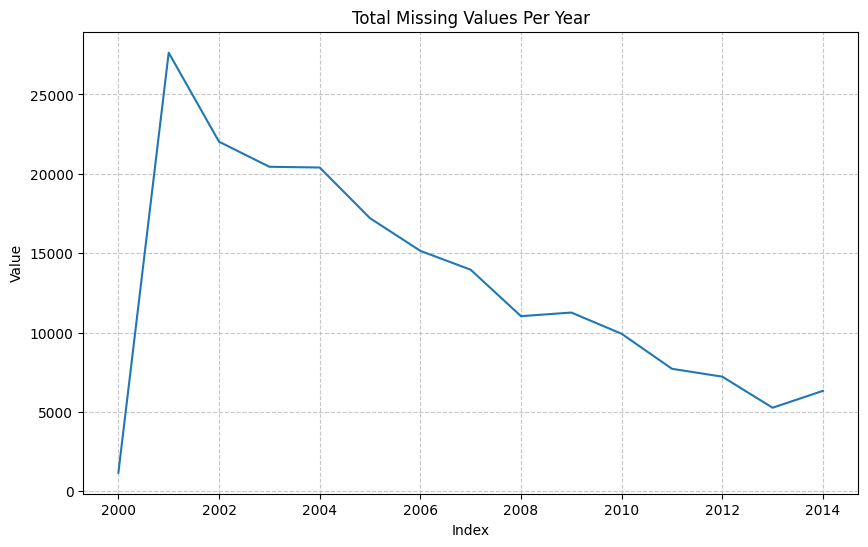

In [11]:
try:
    # 1. Missing per column
    # Exclude 'Date' from the calculation since it's our index/time column
    missing_per_col = df_prices.drop(columns=['Date']).isnull().sum()
    logger.info(f"Top 5 columns with missing values:\n{missing_per_col.sort_values(ascending=False).head()}")
    
    # 2. Missing per year
    # Set Date as index, find nulls, group directly by the year of the index, and sum across all tickers
    missing_per_year = (
        df_prices.set_index('Date')
        .isnull()
        .groupby(lambda date_index: date_index.year)
        .sum()
        .sum(axis=1)
    )
    
    # Plot missing values over time using the helper function
    generate_plot(
        data=missing_per_year, 
        x_col=None, 
        y_col=None, 
        title="Total Missing Values Per Year", 
        filename="missing_values_per_year.png", 
        plot=True, 
        kind='line'
    )
except Exception as e:
    logger.error(f"Error during missing values analysis: {e}")

### Outlier Analysis (Prices)

2026-02-21 18:12:00,863 - INFO - Found 31704 extreme price records.
2026-02-21 18:12:00,950 - INFO - Plot saved to: ../results/plots/average_price_over_time.png


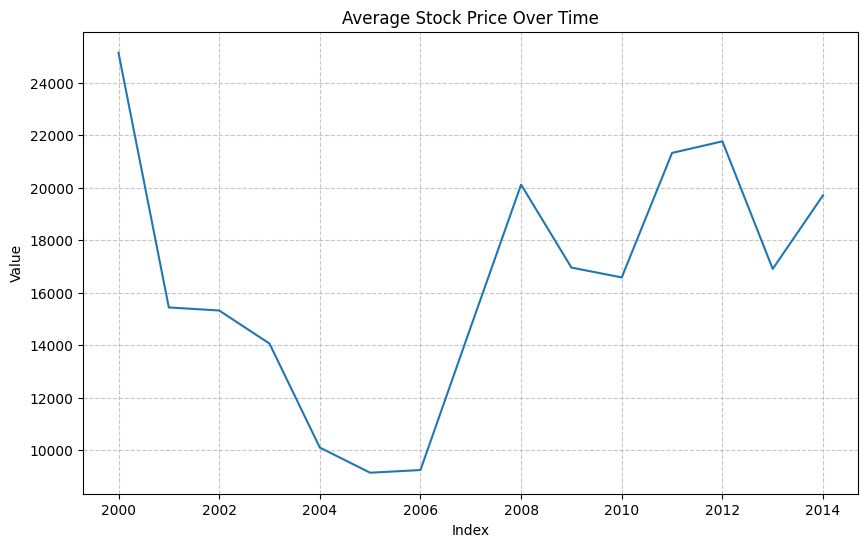

,Date,Ticker,Price
1642830,2012-08-15,SPLS,93870600.0
1643236,2014-03-06,SPLS,69142304.0
1642964,2013-02-19,SPLS,68197696.0
1642505,2011-05-18,SPLS,62315700.0
1642189,2010-03-02,SPLS,49567700.0
1642852,2012-09-14,SPLS,46912200.0
1643095,2013-08-21,SPLS,45490400.0
1642710,2012-02-29,SPLS,43527700.0
1642965,2013-02-20,SPLS,42068600.0
1643360,2014-09-02,SPLS,42005196.0


In [12]:
try:
    # Transform data from wide to long format for easier aggregate analysis
    # FIX: Removed 'Year' from id_vars since we optimized it away in the last step
    prices_melted = df_prices.melt(id_vars=['Date'], var_name='Ticker', value_name='Price')
    prices_melted = prices_melted.dropna(subset=['Price'])
    
    # Identify obvious extreme outliers outside the project bounds [$0.1 to $10,000]
    extreme_prices = prices_melted[(prices_melted['Price'] > 10000) | (prices_melted['Price'] < 0.1)]
    logger.info(f"Found {len(extreme_prices)} extreme price records.")
    
    # Plot average price of companies over time
    # FIX: Extract the year dynamically directly from the Date column
    avg_price_yr = prices_melted.groupby(prices_melted['Date'].dt.year)['Price'].mean()
    
    generate_plot(
        data=avg_price_yr, 
        x_col=None, 
        y_col=None, 
        title="Average Stock Price Over Time", 
        filename="average_price_over_time.png", 
        plot=True, 
        kind='line'
    )
    
    # Display the top extreme records to help manual identification for 'outliers.txt'
    display(extreme_prices.sort_values(by='Price', ascending=False).head(10))
    
except Exception as e:
    logger.error(f"Error during outlier analysis: {e}")